In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
#from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score




In [1]:
#!pip install sagemaker --upgrade

In [4]:
import os
print(os.getcwd())      # shows current directory
print(os.listdir()) 

/Users/chandru/Chandru Files/Data Science/Test CSVs
['.DS_Store', 'anaconda_projects', '.ipynb_checkpoints', 'Accounts Rdm100.csv', 'Testnotebook.ipynb']


In [3]:
indy=pd.read_csv('Indy.csv')

In [4]:
indy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Movie                   104 non-null    object 
 1   Rankings                0 non-null      float64
 2   Scene                   105 non-null    int64  
 3   Scene Description       105 non-null    object 
 4   Time Start              105 non-null    int64  
 5   Time End                105 non-null    int64  
 6   Duration                105 non-null    int64  
 7   Duration Scaled         105 non-null    float64
 8   Quality                 105 non-null    int64  
 9   Adjustment              105 non-null    int64  
 10  Rating                  105 non-null    int64  
 11  Rating Scaled           105 non-null    float64
 12  Iconic                  78 non-null     float64
 13  Infamous                34 non-null     float64
 14  Iconic Scaled           34 non-null     fl

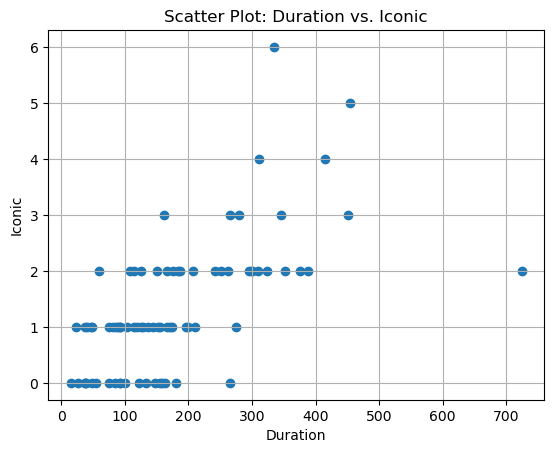

In [39]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

plt.scatter(indy["Duration"], indy["Iconic"])
plt.xlabel("Duration")
plt.ylabel("Iconic")
plt.title("Scatter Plot: Duration vs. Iconic")
plt.grid(True)
plt.show()


In [30]:
indy.where(indy['Iconic']>50)

,Movie,Rankings,Scene,Scene Description,Time Start,Time End,Duration,Duration Scaled,Quality,Adjustment,...,Short Impact,Shorty In Scene,MolaRam Impact,MolaRam In Scene,Donovan Impact,Donovan In Scene,Elsa Impact,Elsa In Scene,Vogel Impact,Vogel In Scene
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
raiders = indy[indy['Movie'] == 'Raiders of the Lost Ark']


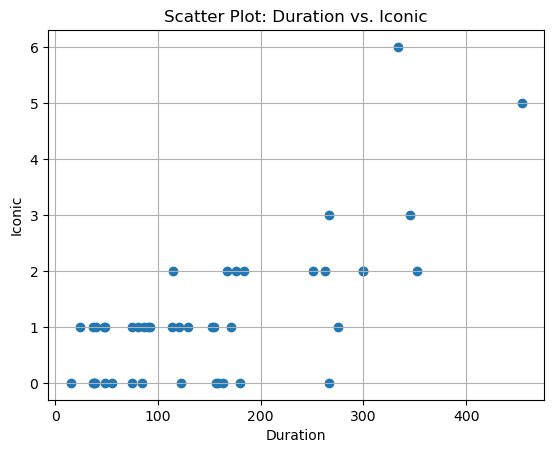

In [40]:
plt.scatter(raiders["Duration"], raiders["Iconic"])
plt.xlabel("Duration")
plt.ylabel("Iconic")
plt.title("Scatter Plot: Duration vs. Iconic")
plt.grid(True)
plt.show()

In [42]:
raiders['Iconic'].mean()

1.1818181818181819

In [41]:
raiders['Iconic']

0     2.0
1     6.0
2     2.0
3     1.0
4     2.0
5     1.0
6     1.0
7     2.0
8     3.0
9     0.0
10    2.0
11    0.0
12    1.0
13    0.0
14    1.0
15    1.0
16    0.0
17    1.0
18    0.0
19    1.0
20    0.0
21    1.0
22    1.0
23    0.0
24    2.0
25    0.0
26    2.0
27    2.0
28    0.0
29    0.0
30    3.0
31    1.0
32    5.0
33    1.0
34    1.0
35    1.0
36    0.0
37    1.0
38    0.0
39    0.0
40    2.0
41    1.0
42    0.0
43    1.0
Name: Iconic, dtype: float64

In [43]:
X=raiders[['Duration']]

In [44]:
y=raiders[['Iconic']]

In [45]:
X.index = raiders["Scene Description"]
y.index = raiders["Scene Description"]

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=100)

In [47]:
model=LinearRegression()

In [48]:
model.fit(X_train, y_train)

LinearRegression()

In [49]:
y_pred=model.predict(X_test)

In [50]:
res=y_test-y_pred

,Iconic
Scene Description,
Indy Flying to Nepal,0.521590
Toht with Scar,0.826361
Finding Well of the Souls,-0.103992
belloq Annoyed at Dietrich,0.002807
Sub Goes to Island,0.473468
Ark in Warehouse,0.738137
Indy and Brody at Indy's House,0.208799
Indy and Sallah Find the Ark,-0.550593
Escaping Well of Souls,0.711542


In [78]:
#res

In [79]:
r2 = r2_score(y_test, y_pred)

In [80]:
r2

0.7302813751960688

In [58]:
pd.Series(y_pred.ravel()).value_counts().sort_index()
#Yes theres a negative prediction, lets do possion whch restricts to positve predictons.

-0.002807    1
 0.173639    1
 0.261863    1
 0.478410    1
 0.526532    1
 0.550593    1
 0.614755    1
 0.791201    1
 0.839323    1
 0.855363    1
 1.103992    1
 1.288458    1
 1.889980    1
 1.986223    1
 2.282973    1
 3.518097    1
Name: count, dtype: int64

In [52]:
mae=mean_absolute_error(y_test,y_pred)
mae

0.46420298775237195

In [53]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
rmse

0.6011495768127447

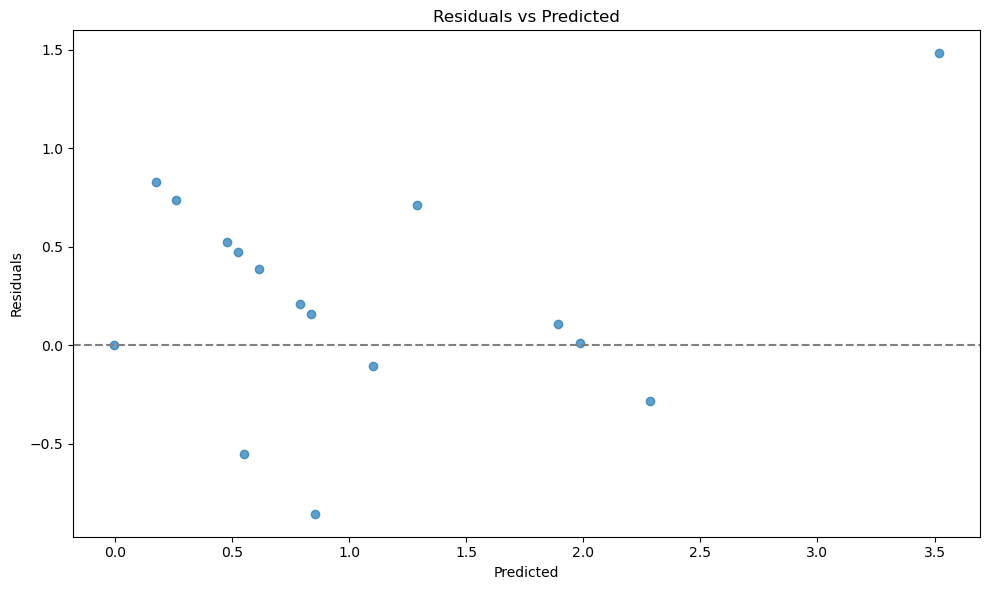

In [68]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, res, alpha=0.7)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

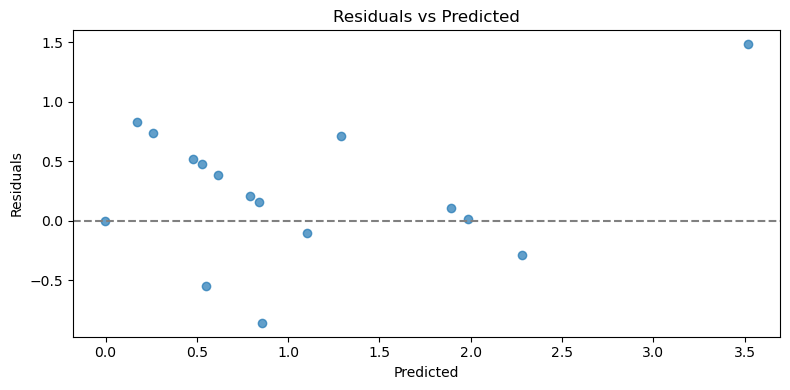

In [69]:
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, res, alpha=0.7)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

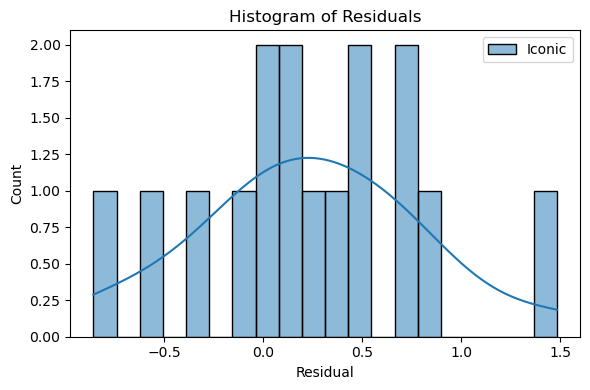

In [72]:
plt.figure(figsize=(6, 4))
sns.histplot(res, kde=True, bins=20)
plt.xlabel("Residual")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

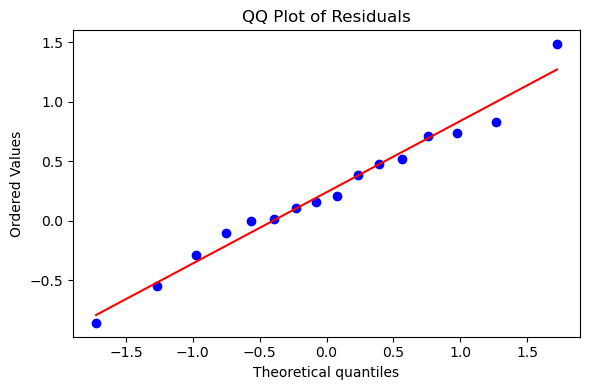

In [76]:


plt.figure(figsize=(6, 4))
stats.probplot(np.array(res).ravel(), dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()



In [62]:
#need to move to Poisson Regression or Ridge/Lasso but dont need to scale, we just have 1 feature.
model2=PoissonRegressor()
model2.fit(X_train, y_train)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


PoissonRegressor()

In [64]:
ypois_pred=model2.predict(X_test)

In [65]:
maepois=mean_absolute_error(y_test,ypois_pred)
maepois

0.5137001248390101

In [66]:
rmsepois=np.sqrt(mean_squared_error(y_test,ypois_pred))
rmsepois

0.6012284116867521

In [88]:
respois=np.ravel(y_test)-np.ravel(ypois_pred)

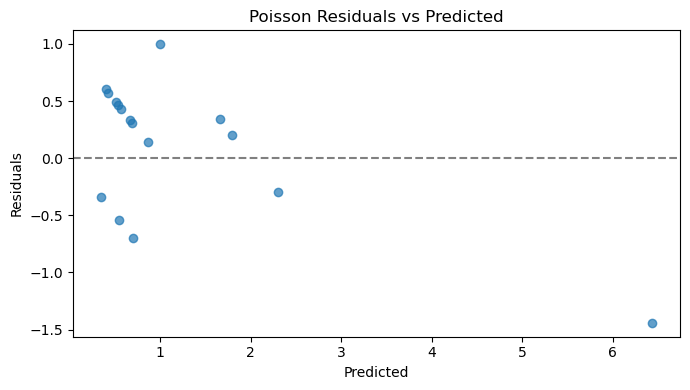

In [91]:
plt.figure(figsize=(7, 4))
plt.scatter(ypois_pred, respois, alpha=0.7)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Poisson Residuals vs Predicted")
plt.tight_layout()
plt.show()

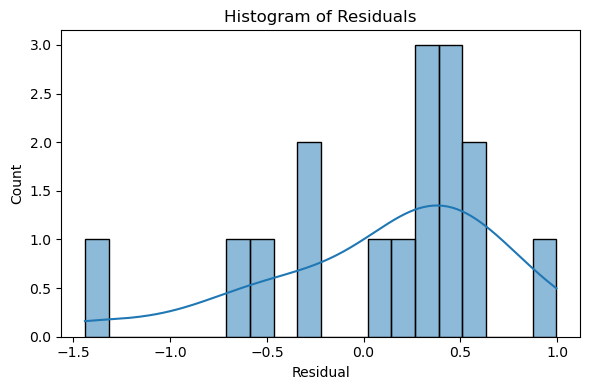

In [92]:
plt.figure(figsize=(6, 4))
sns.histplot(respois, kde=True, bins=20)
plt.xlabel("Residual")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

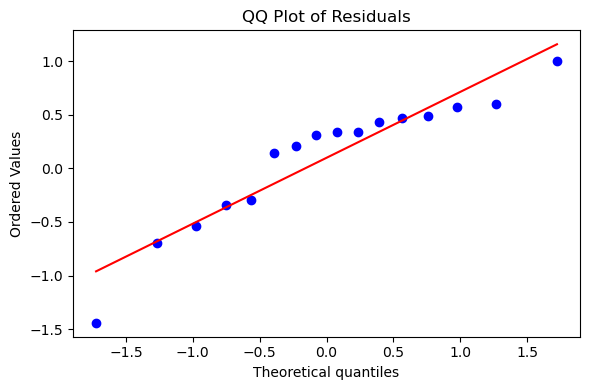

In [93]:
plt.figure(figsize=(6, 4))
stats.probplot(np.array(respois).ravel(), dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

In [94]:
r2pois = r2_score(y_test, ypois_pred)
r2pois

0.7302106286502626